In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import arviz as az
az.style.use("arviz-doc")

from helper import load_params_csv
from run import run_sim

In [3]:
#helper settings
companies = {
    'IP':'Interpump Group',
    'GGG':'Graco Inc.',
    'ALFA':'Alfa Laval AB',
    'REC':'Recordati S.p.A.'
}

cmap = {
    'blue': '#0000FF',#17375E
    'yellow': '#FFF44F',
    'red': '#800000',
    'green': '#4CA877',
    'grey': '#CCD1D7',
    'gold': '#C89700'
}

In [5]:
def add_note_below_legend(ax, text, ypad=0.02, xpad=0.06, fontsize=9):
    fig = ax.figure
    legend = ax.get_legend()
    fig.canvas.draw()

    bbox = legend.get_window_extent()
    bbox_ax = bbox.transformed(ax.transAxes.inverted())

    ax.text(
        bbox_ax.x0 + xpad,
        bbox_ax.y0 - ypad,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=fontsize
    )

In [187]:
company = 'IP'

In [189]:
params = load_params_csv('params/' + company + '_model.csv')
params['mu_tv'] = 0.02
risk_free = params['r_bar']
params['rho'] = params['r_bar'] + params['pi']
params

{'R_0': 2078.39,
 'mu_0': 0.0015,
 'mu_hat': 0.0877,
 'kappa_mu': 0.2772,
 'sigma': 0.1852,
 'eta': 0.055,
 'theta': 0.636,
 'gamma': 0.0962,
 'F_0': 12.21,
 'tau': 0.24,
 'r_bar': 0.02415,
 'pi': 0.05327,
 'rho12': 0.0,
 'mu_tv': 0.02,
 'rho': 0.07742}

In [191]:
#deal parameters
alpha = 0.0
spread = 0.05

params['r_bar'] = risk_free + spread

#time parameters
T = 10
t_exit = 5
n_steps = T * 52 + 1
n_exit = min(t_exit * 52 + 1, n_steps-1)
y_0 = 2024
grid = np.linspace(y_0, y_0+T, n_steps)

#siulation
n_paths = 1_000
output = run_sim(
    params,
    n_steps=n_steps,
    n_paths=n_paths,
    T = T,
    t_exit=t_exit,
    alpha=alpha,
    seed=99,
    stochastic_ir = False,
    return_all = True
)

In [54]:
default_rate = output['defaulted'][:, -1].mean()
default_rate

0.0

In [15]:
earliest_path = int((np.where(output['D'] < 1e-6, np.arange(n_exit), n_exit).min(axis=1)).argmin())

final_cf = output['CF'][:, -2]
positive_mask = final_cf > 0
positive_indices = np.where(positive_mask)[0]
mean_path = positive_indices[np.abs(final_cf[positive_indices] - final_cf[positive_mask].mean()).argmin()]

second_last_cf = output['CF'][:, -2]
zero_indices = np.where((np.abs(second_last_cf) < 1e-6) & ~output['defaulted'][:, -1])[0]
zero_path = zero_indices[0]

print(earliest_path, mean_path, zero_path)

208 407 0


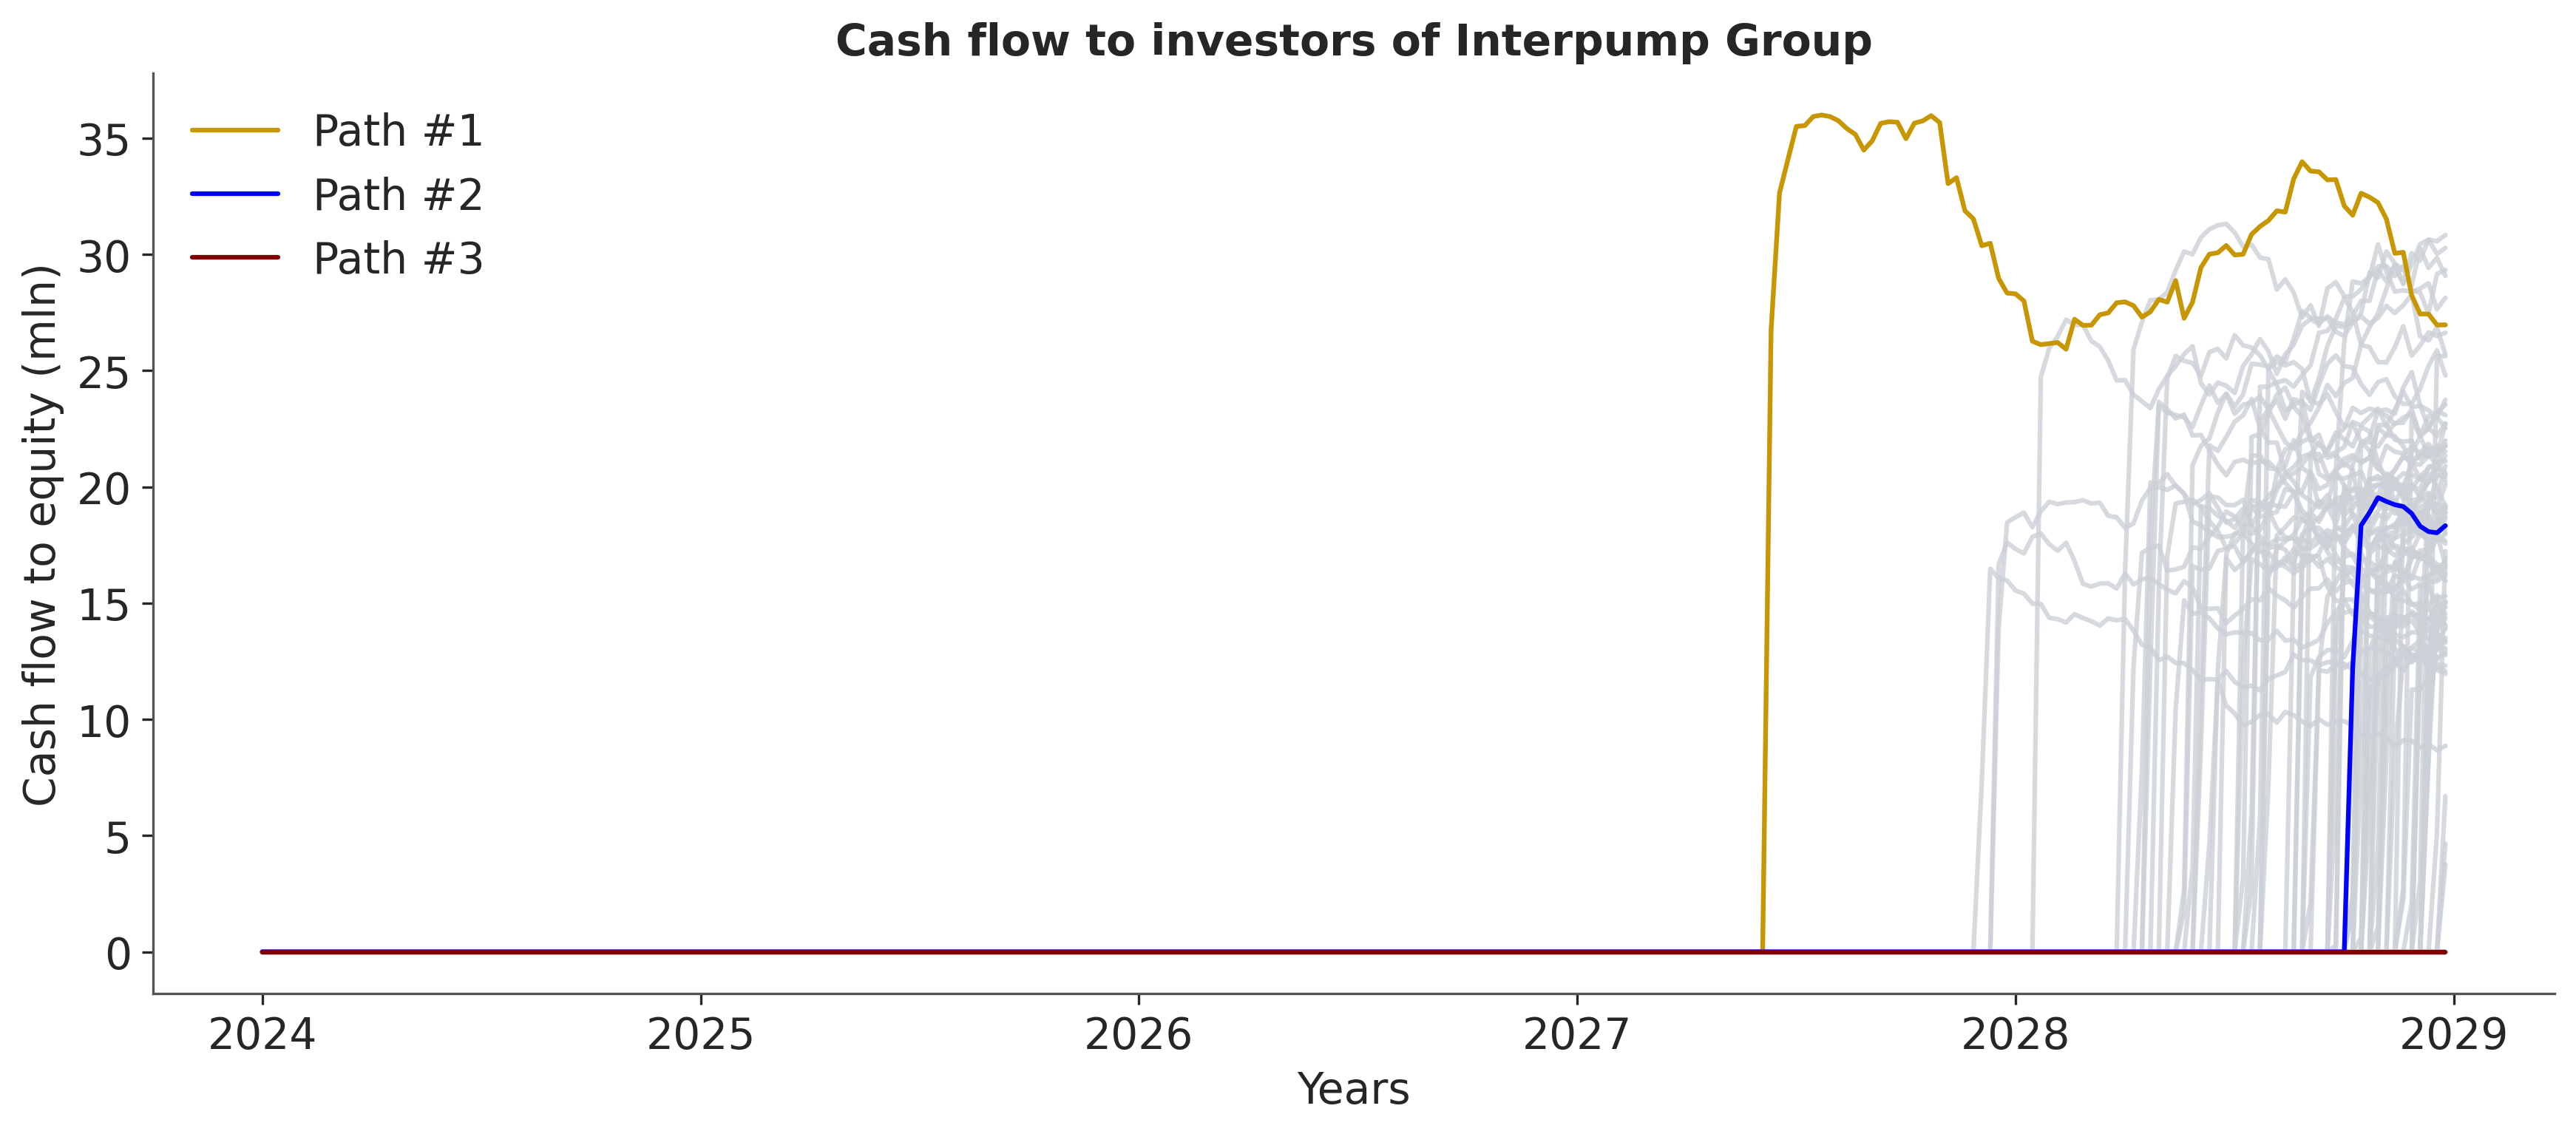

In [17]:
fig, ax = plt.subplots()
for path in output['CF'][:]:
    ax.plot(grid[:n_exit-1], path[:n_exit-1], alpha=0.8, color=cmap['grey'])
ax.plot(grid[:n_exit-1], output['CF'][earliest_path][:n_exit-1], alpha=1, color=cmap['gold'], label='Path #1')
ax.plot(grid[:n_exit-1], output['CF'][mean_path][:n_exit-1], alpha=1, color=cmap['blue'], label='Path #2')
ax.plot(grid[:n_exit-1], output['CF'][zero_path][:n_exit-1], alpha=1, color=cmap['red'], label='Path #3')
#ax.plot(grid[:-1], [0] * (n_steps - 1), alpha=1, color=cmap['red'], label='Path #3')

ax.set_title(f'Cash flow to investors of {companies[company]}', fontsize=14)
ax.set_xlabel("Years")
ax.set_ylabel("Cash flow to equity (mln)")

ax.legend(loc='upper left')

#plt.savefig(f'images/{company}_cashflows.png', dpi=200, bbox_inches='tight')
plt.show()

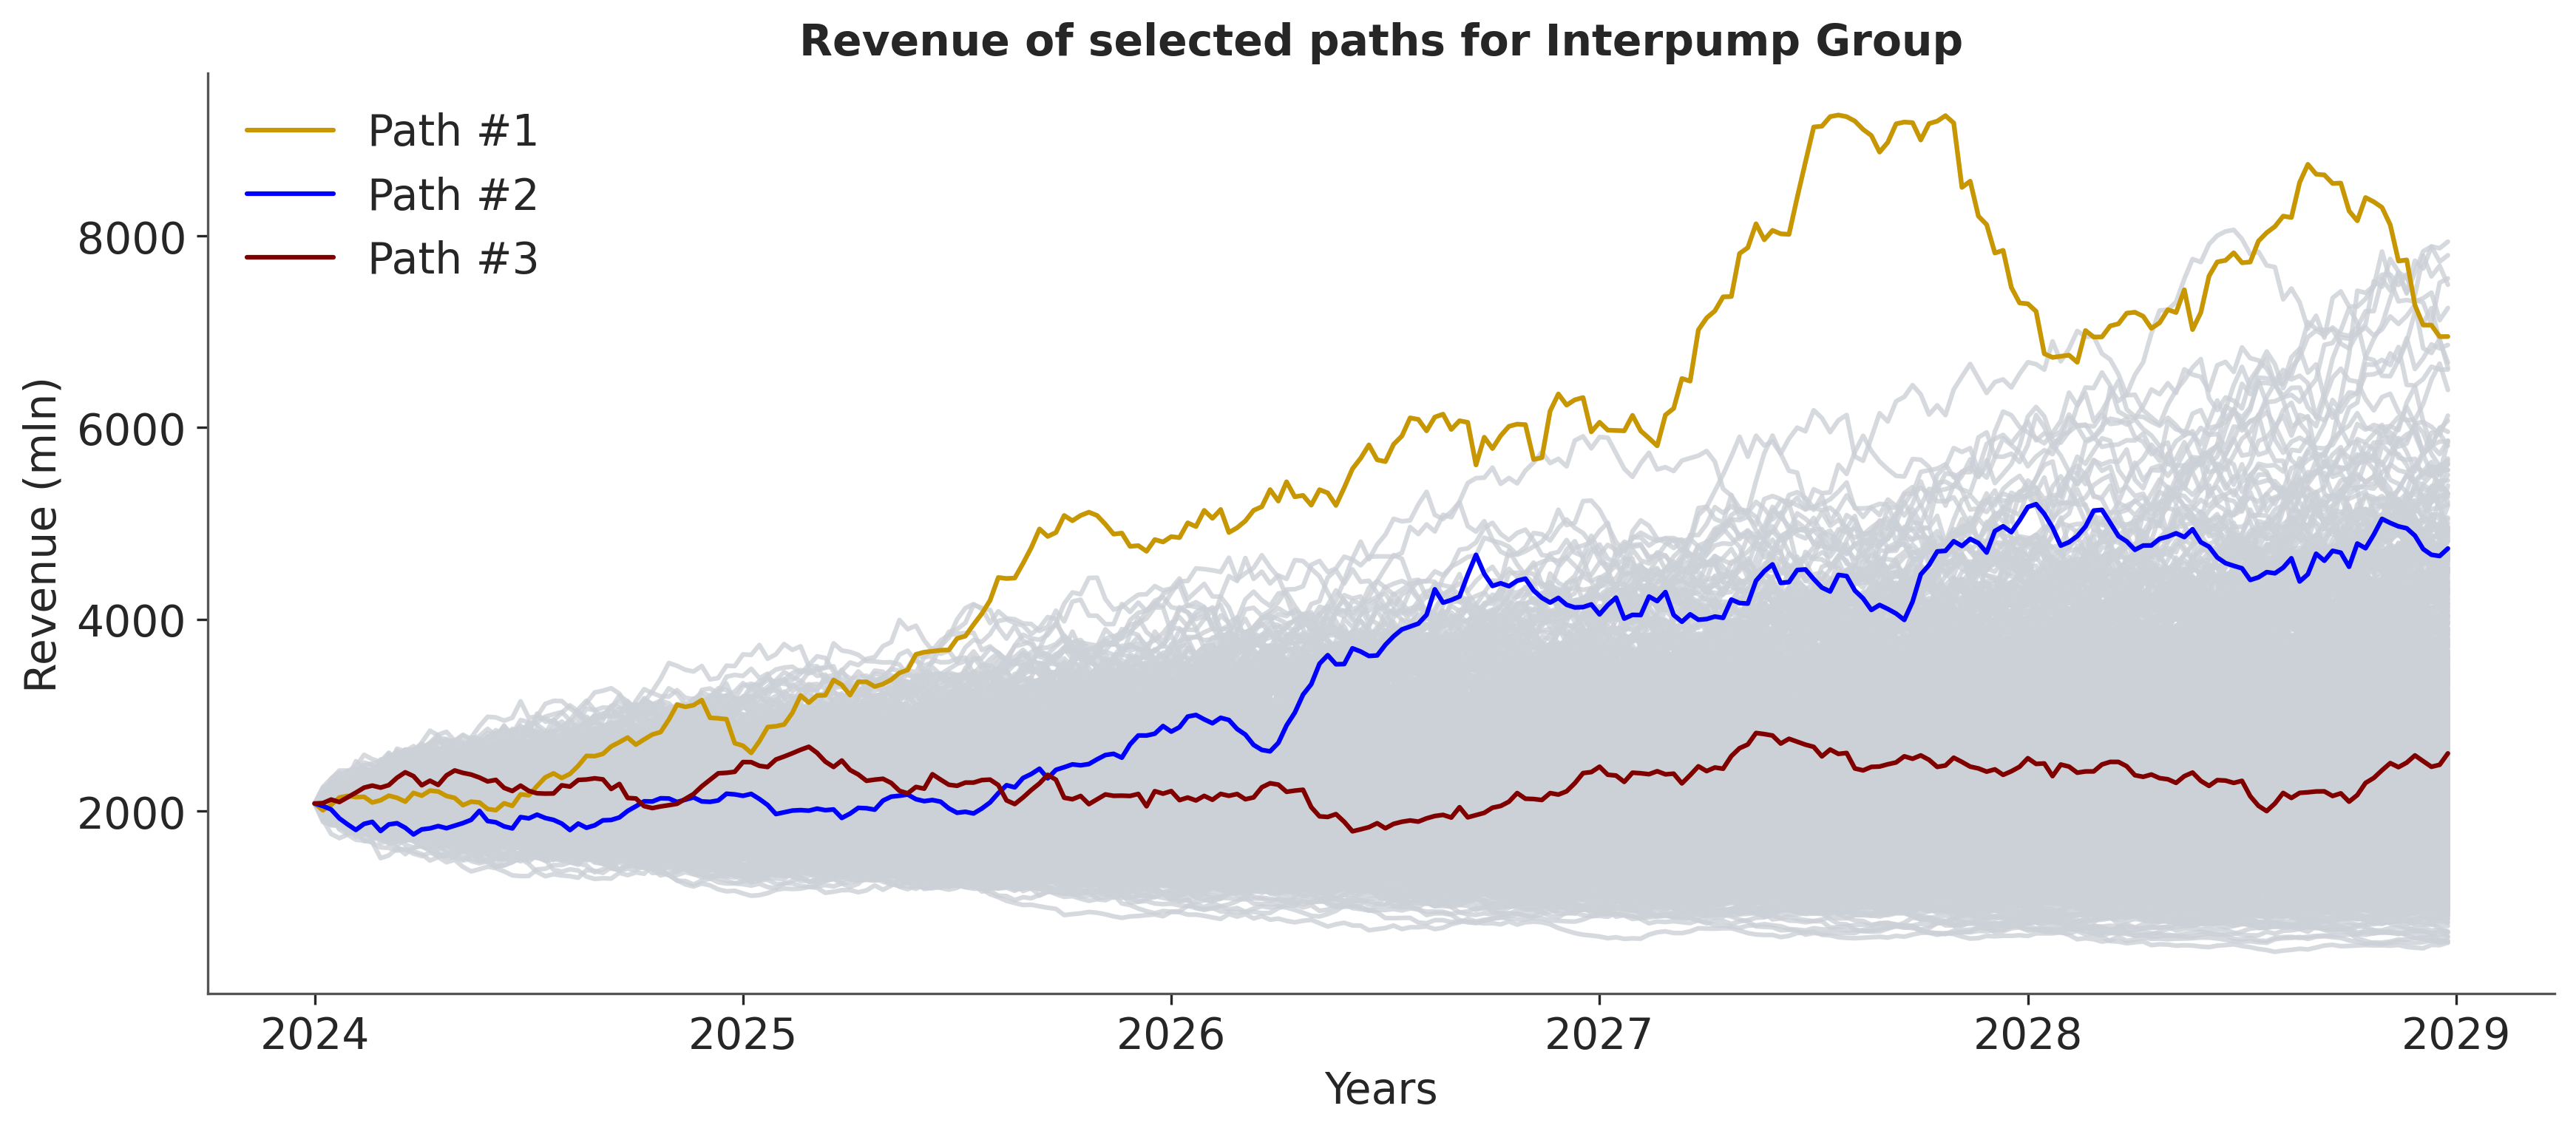

In [19]:
fig, ax = plt.subplots()
for path in output['R'][:]:
    ax.plot(grid[:n_exit-1], path[:n_exit-1], alpha=0.8, color=cmap['grey'])
ax.plot(grid[:n_exit-1], output['R'][earliest_path][:n_exit-1], alpha=1, color=cmap['gold'], label='Path #1')
ax.plot(grid[:n_exit-1], output['R'][mean_path][:n_exit-1], alpha=1, color=cmap['blue'], label='Path #2')
ax.plot(grid[:n_exit-1], output['R'][zero_path][:n_exit-1], alpha=1, color=cmap['red'], label='Path #3')

ax.set_title(f'Revenue of selected paths for {companies[company]}', fontsize=14)
ax.set_xlabel("Years")
ax.set_ylabel("Revenue (mln)")

ax.legend(loc='upper left')

#plt.savefig(f'images/{company}_cf_revs.png', dpi=200, bbox_inches='tight')
plt.show()

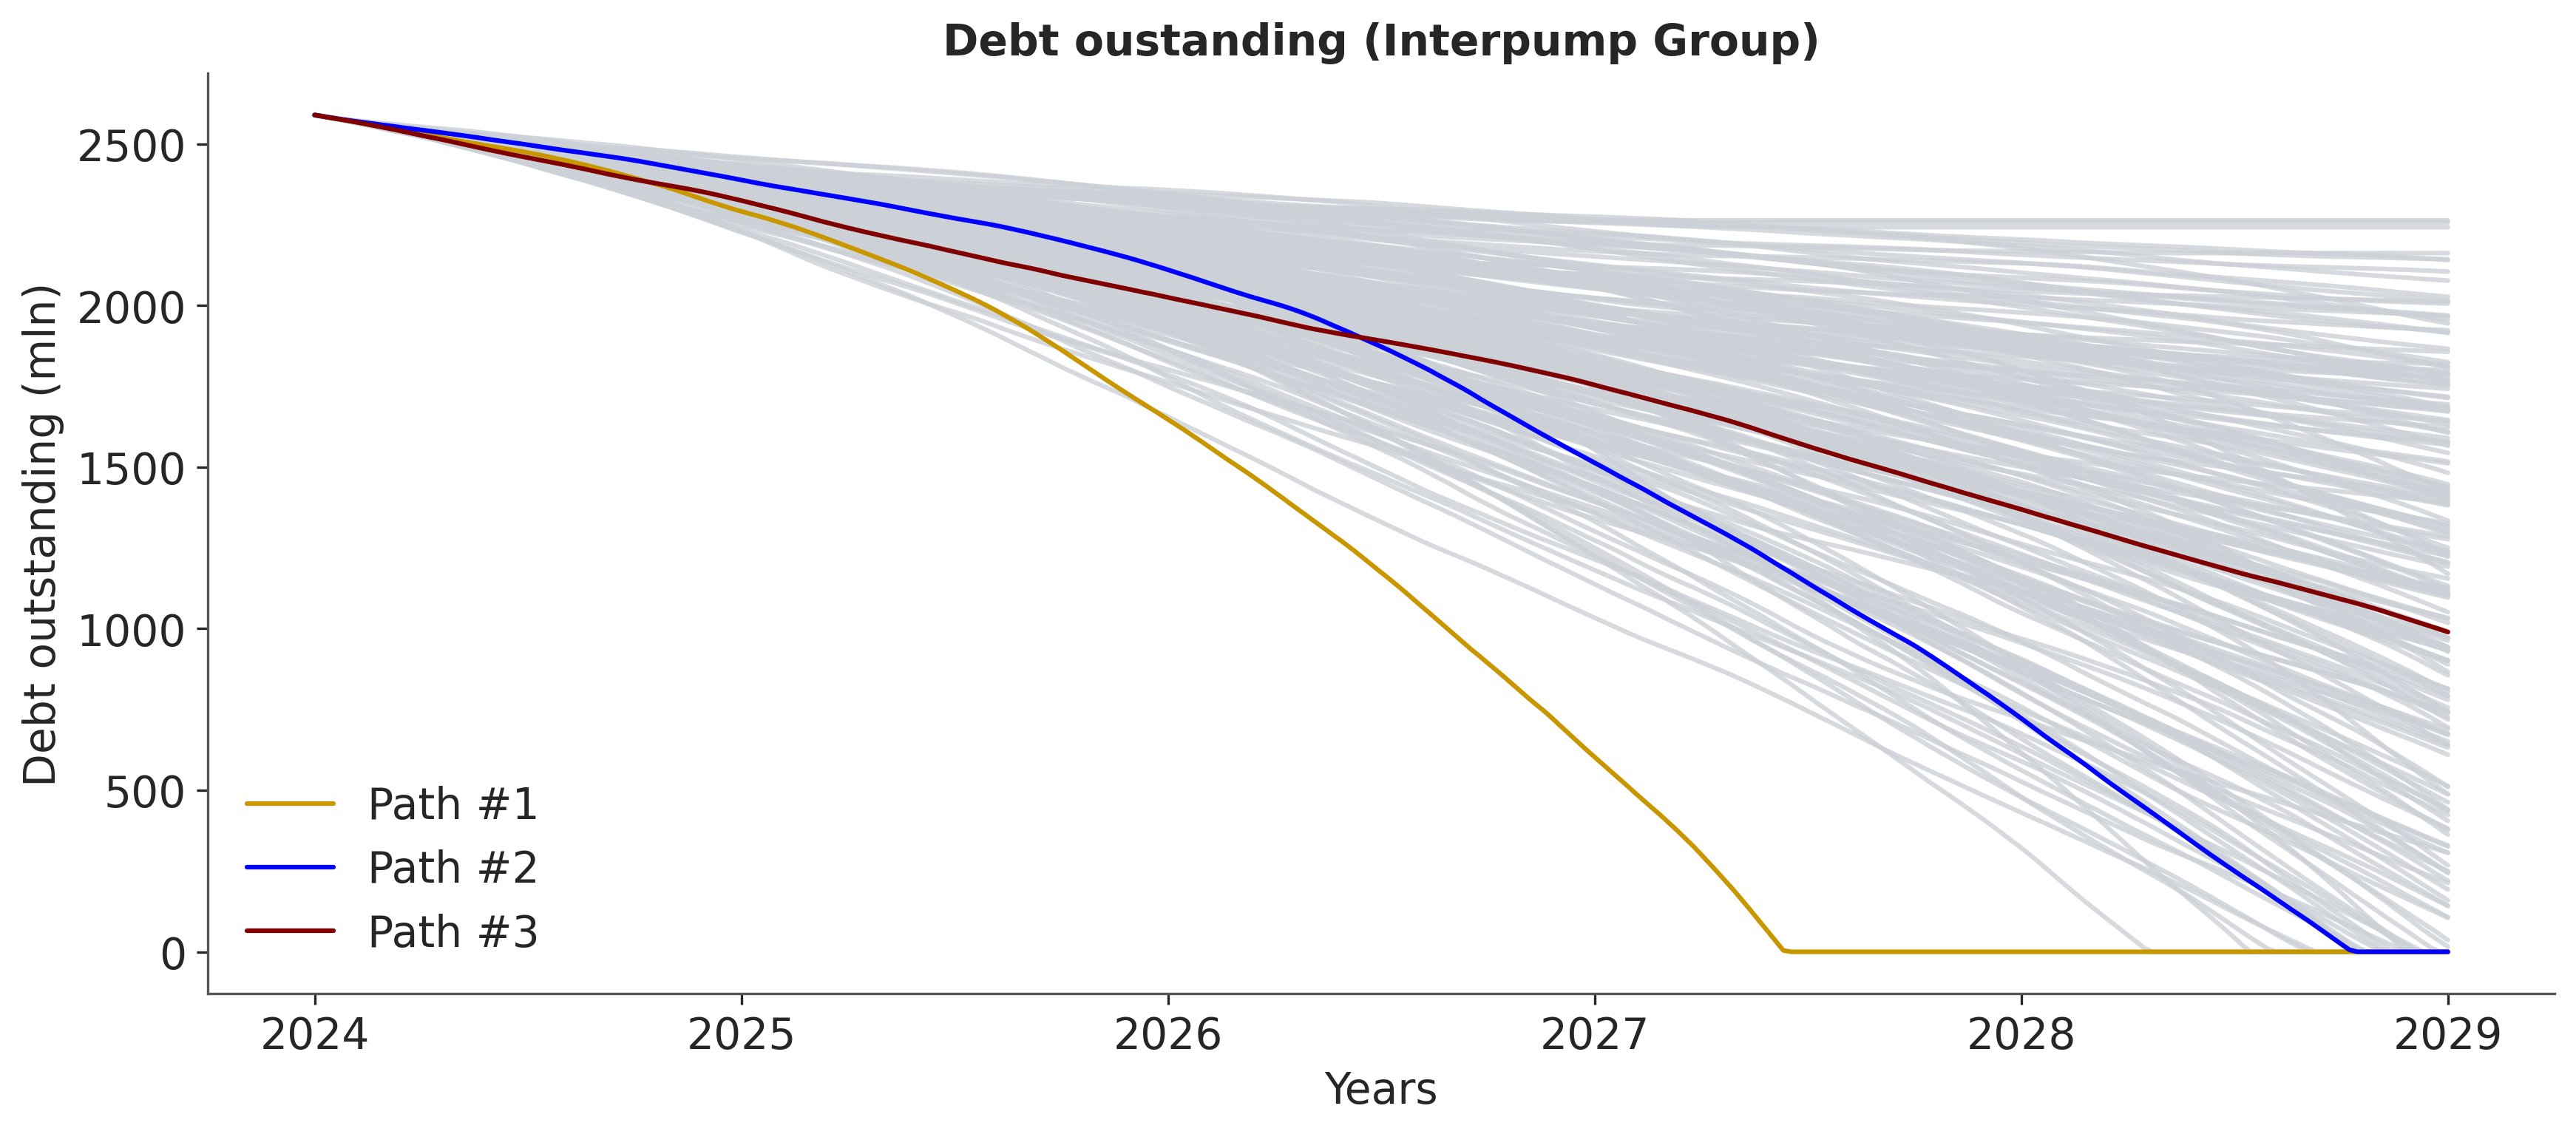

In [21]:
fig, ax = plt.subplots()
for path in output['D'][:200]:
    ax.plot(grid[:n_exit], path, alpha=0.8, color=cmap['grey'])
ax.plot(grid[:n_exit], output['D'][earliest_path], alpha=1, color=cmap['gold'], label='Path #1')
ax.plot(grid[:n_exit], output['D'][mean_path], alpha=1, color=cmap['blue'], label='Path #2')
ax.plot(grid[:n_exit], output['D'][zero_path], alpha=1, color=cmap['red'], label='Path #3')

ax.set_title(f'Debt oustanding ({companies[company]})', fontsize=14)
ax.set_xlabel("Years")
ax.set_ylabel("Debt outstanding (mln)")

ax.legend(loc='lower left')

#plt.savefig(f'images/{company}_debt.png', dpi=200, bbox_inches='tight')
plt.show()

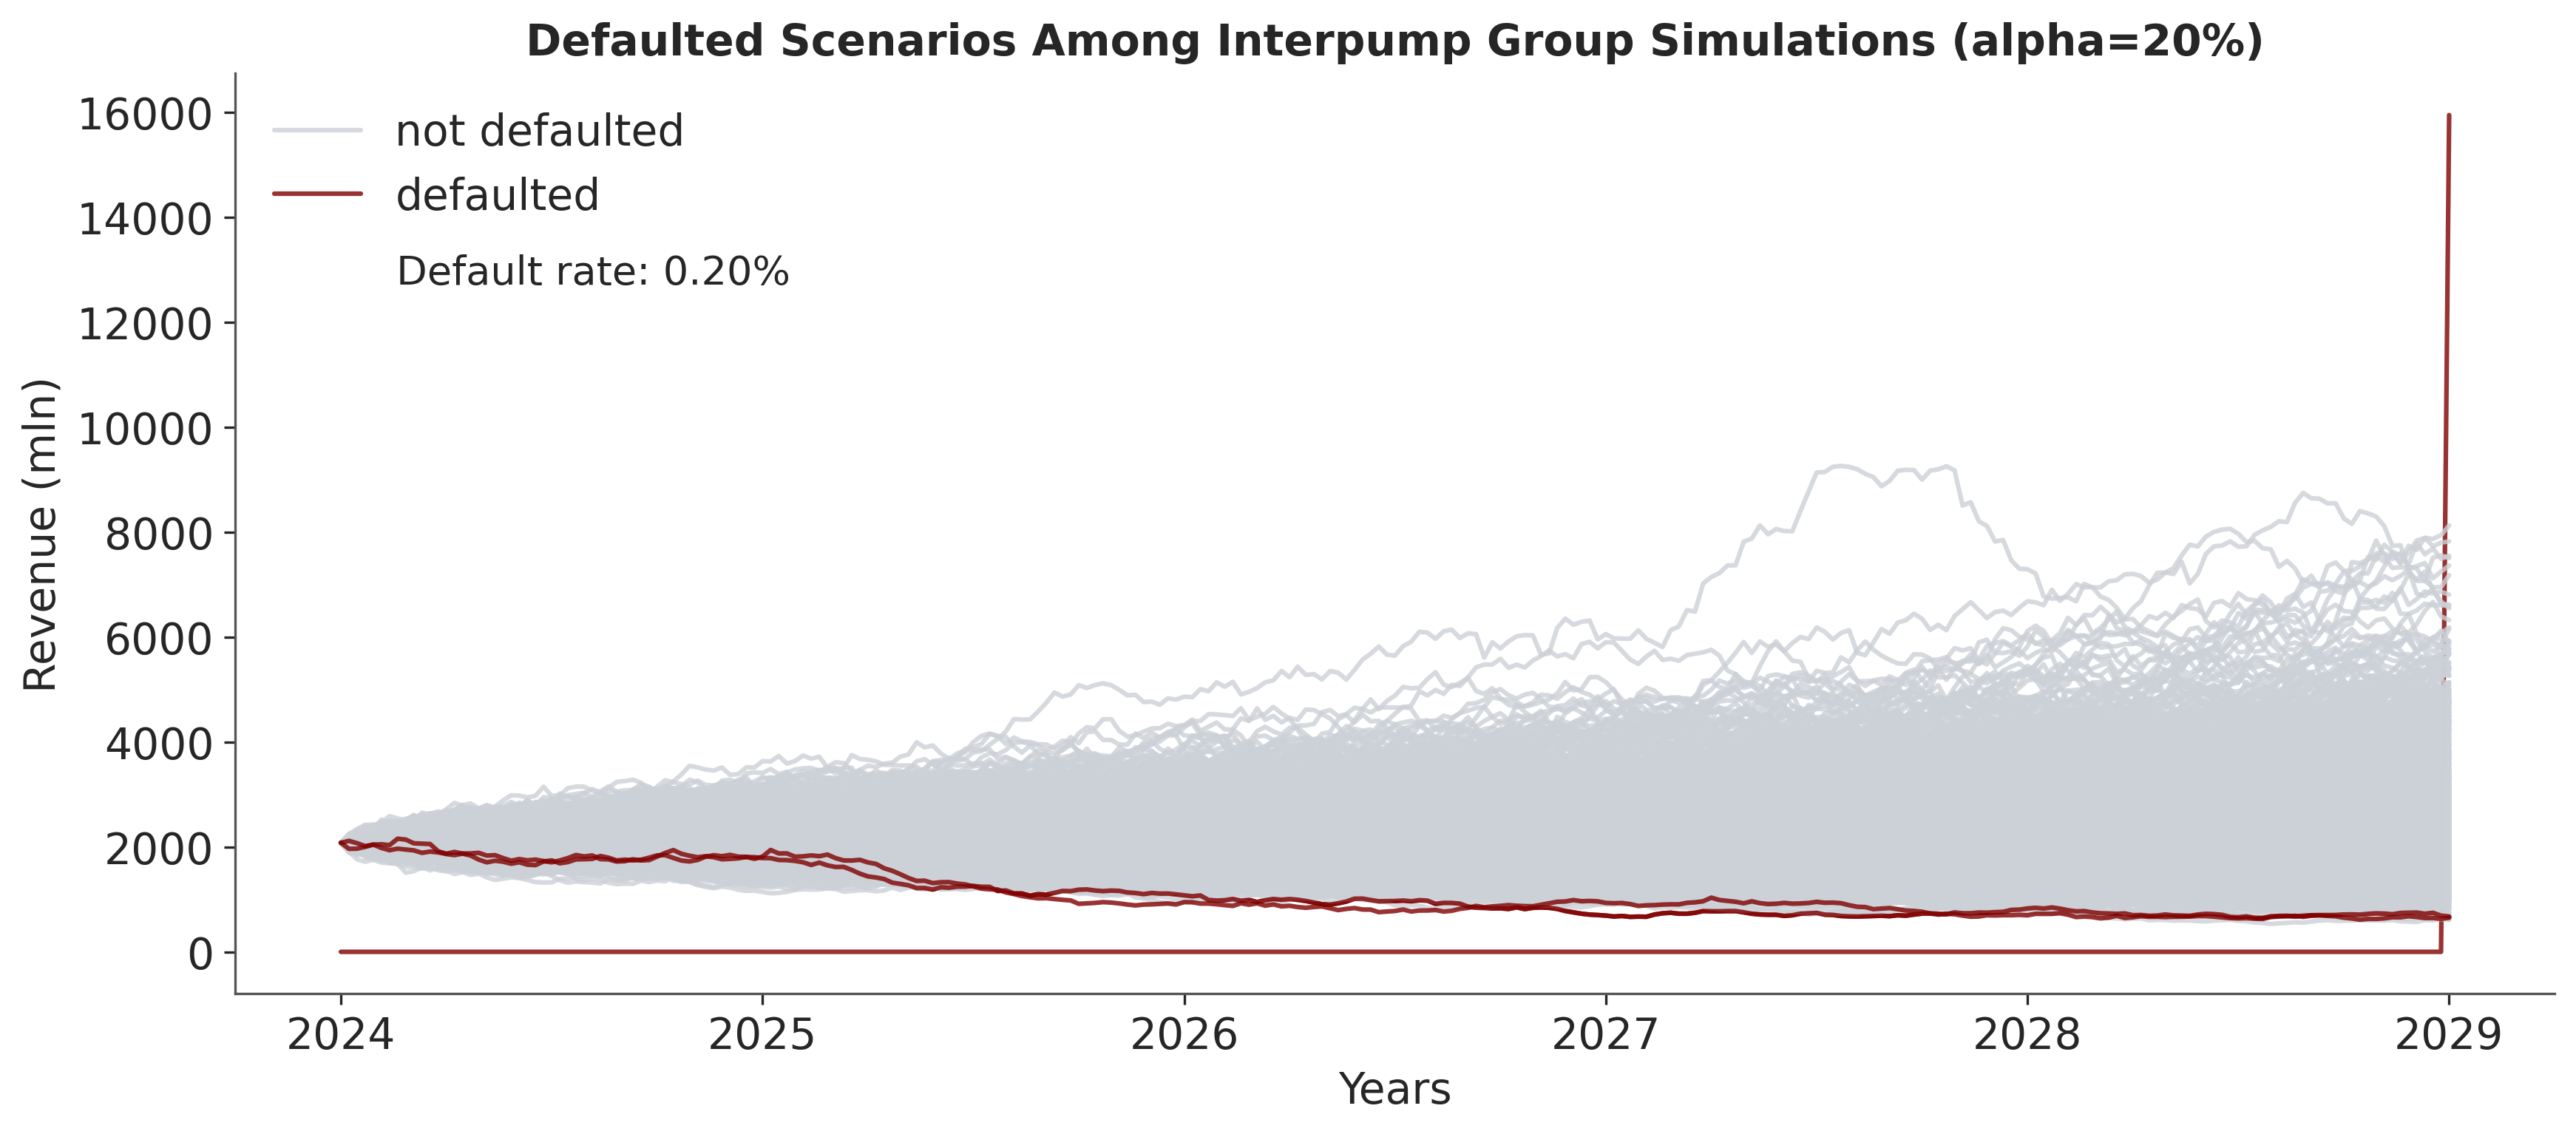

In [239]:
defaulted_indices = np.where(output['defaulted'][:, n_exit-1])[0]
non_defaulted_indices = np.where(~output['defaulted'][:, n_exit-1])[0]


fig, ax = plt.subplots()

#paths for legend
ax.plot(grid[:n_exit], output['R'][non_defaulted_indices[0]][:n_exit], alpha=0.8, color=cmap['grey'], label='not defaulted')
ax.plot(grid[:n_exit], output['R'][defaulted_indices[0]][:n_exit], alpha=0.8, color=cmap['red'], label='defaulted')

#rest of paths
ax.plot(grid[:n_exit], path[:n_exit], alpha=0.8, color=cmap['red'])
for path in output['R'][non_defaulted_indices]:
    ax.plot(grid[:n_exit], path[:n_exit], alpha=0.8, color=cmap['grey'])
for path in output['R'][defaulted_indices]:
    ax.plot(grid[:n_exit], path[:n_exit], alpha=0.8, color=cmap['red'])

ax.set_title(f'Defaulted Scenarios Among {companies[company]} Simulations (alpha={alpha:.0%})', fontsize=14)
ax.set_xlabel("Years")
ax.set_ylabel("Revenue (mln)")

ax.legend(loc='upper left')

annotate_text = f'Default rate: {default_rate:.2%}'
add_note_below_legend(ax, annotate_text, fontsize = 13)


#plt.savefig(f'images/{company}_defaulted_{alpha}.png', dpi=200, bbox_inches='tight')
plt.show()

In [62]:
entry_equity = (output['V_entry'] - output['D'][:, 0].mean())

interim_cf = output['CF'][:, :-1].sum(axis=1)
final_cf = np.maximum(output['V_exit'] - output['D'][:, -1], 0)

payoff = final_cf + interim_cf

defaulted_mask = output['defaulted'][:, -1]
payoff[defaulted_mask] = 0.0

# MOIC
moic = payoff / entry_equity

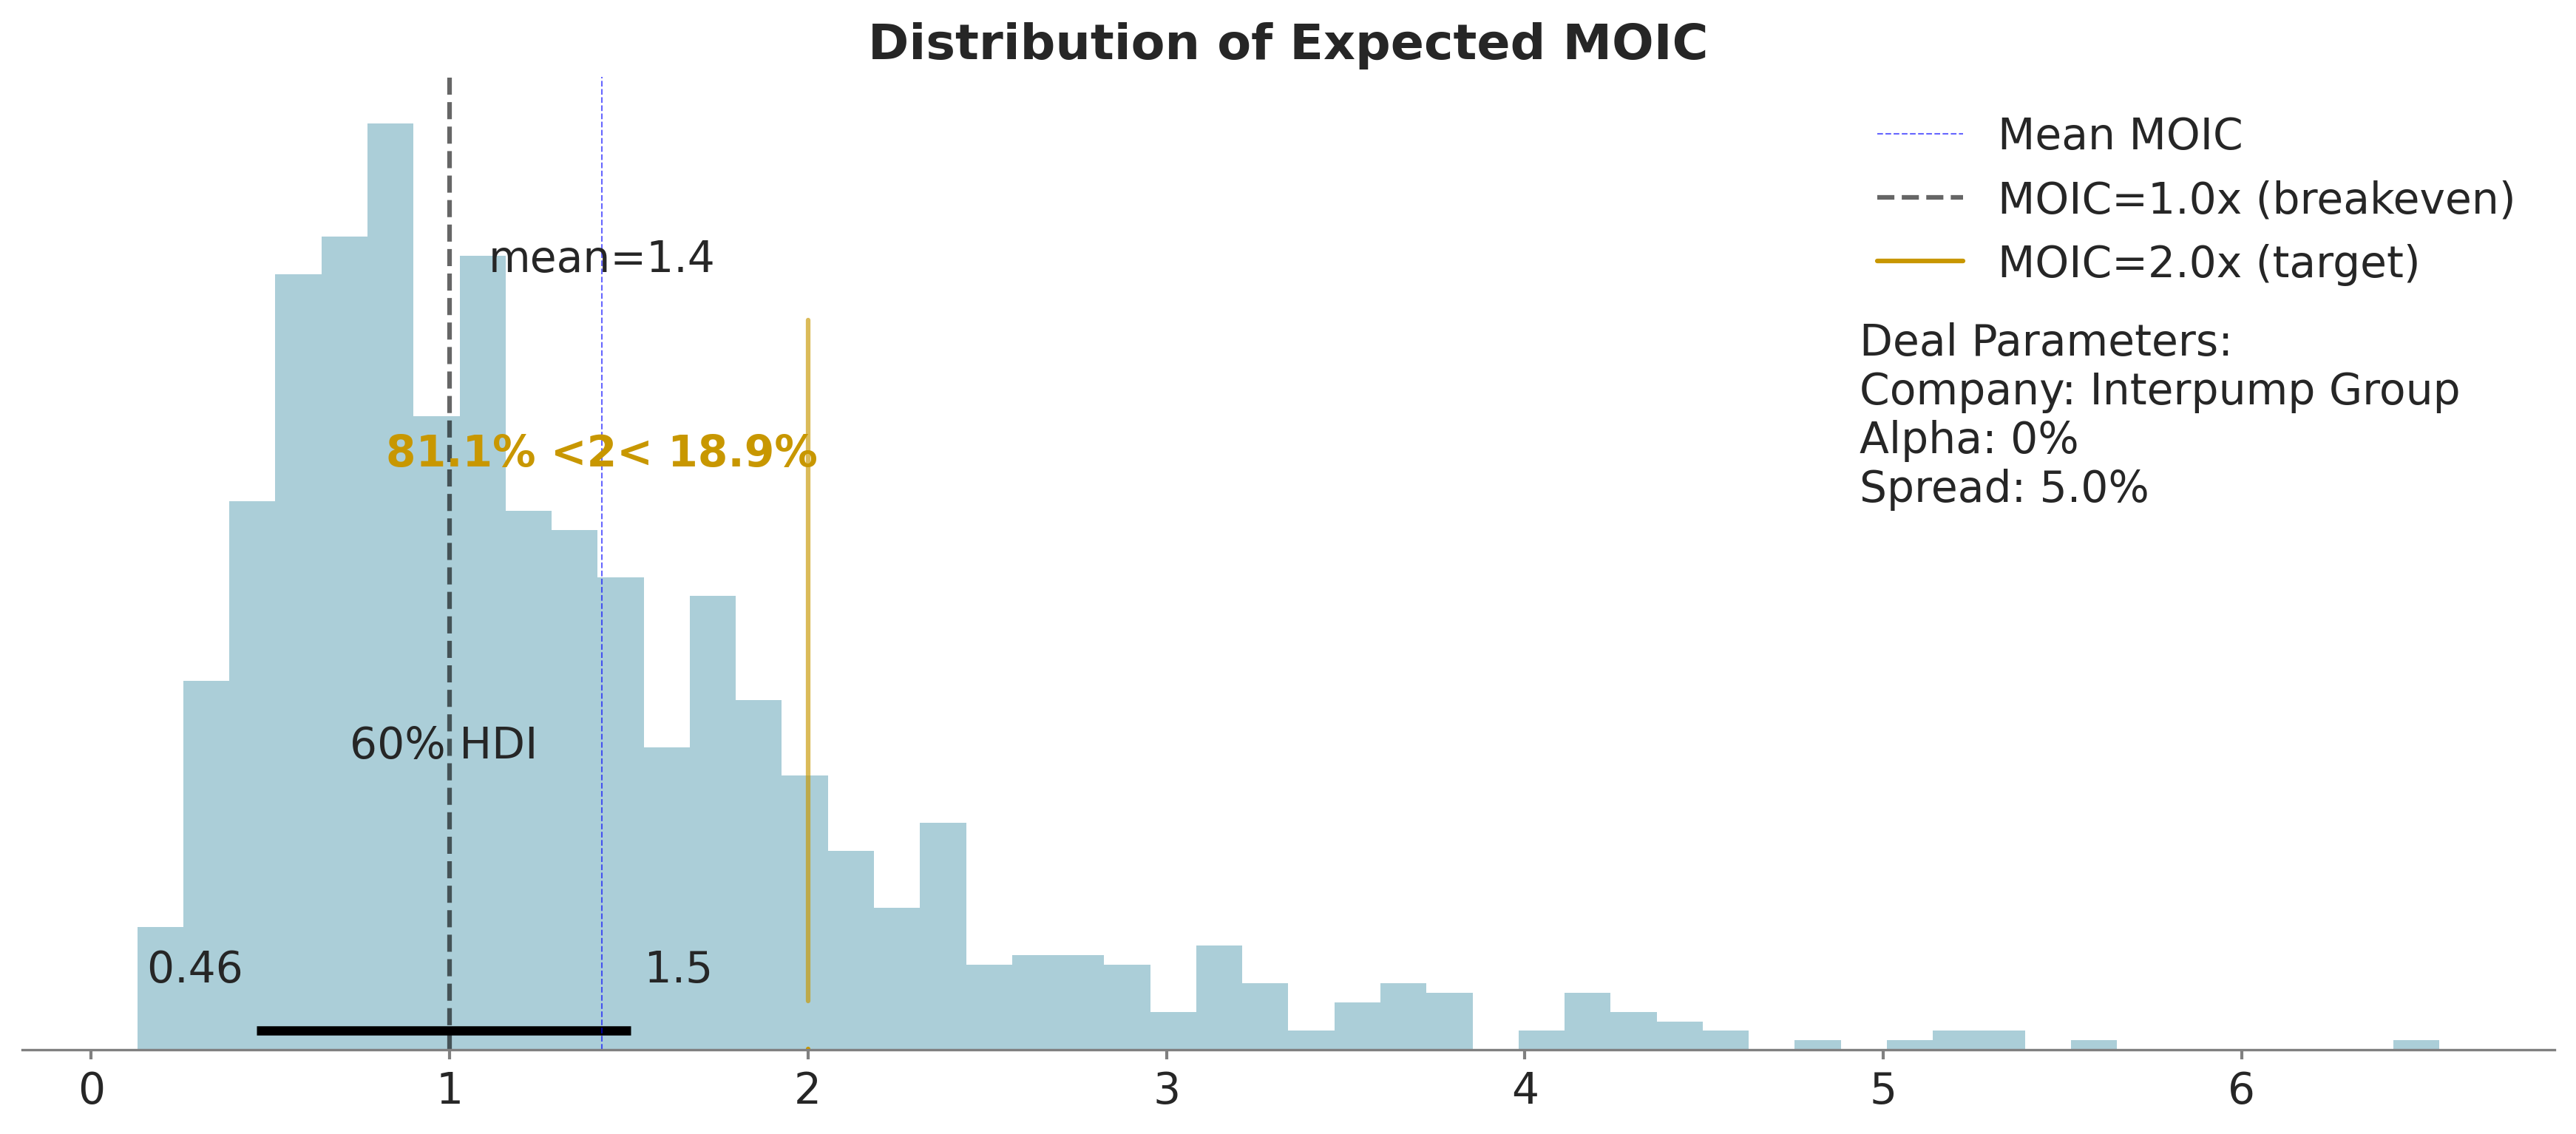

In [64]:
target_moic = 2

ax = az.plot_posterior(
    data = moic,
    kind='hist',
    bins=50,
    ref_val=target_moic,
    hdi_prob=0.6,
    ref_val_color=cmap['gold']
)

ax.axvline(moic.mean(), linestyle='--', color=cmap['blue'], label='Mean MOIC', alpha=0.6, lw=0.5)
ax.axvline(1, linestyle='--', color='black', label='MOIC=1.0x (breakeven)', alpha=0.6)
ax.axvline(target_moic, ymax=0.001, c=cmap['gold'], label='MOIC=2.0x (target)', alpha=1)
ax.set_title('Distribution of Expected MOIC')
ax.legend(loc='upper right')
text = f'Deal Parameters:\nCompany: {companies[company]}\nAlpha: {alpha:.0%}\nSpread: {spread:.1%}'
add_note_below_legend(ax, text, fontsize = 14, xpad=0)


plt.savefig(f'images/{company}_moic_{alpha}.png', dpi=200, bbox_inches='tight')

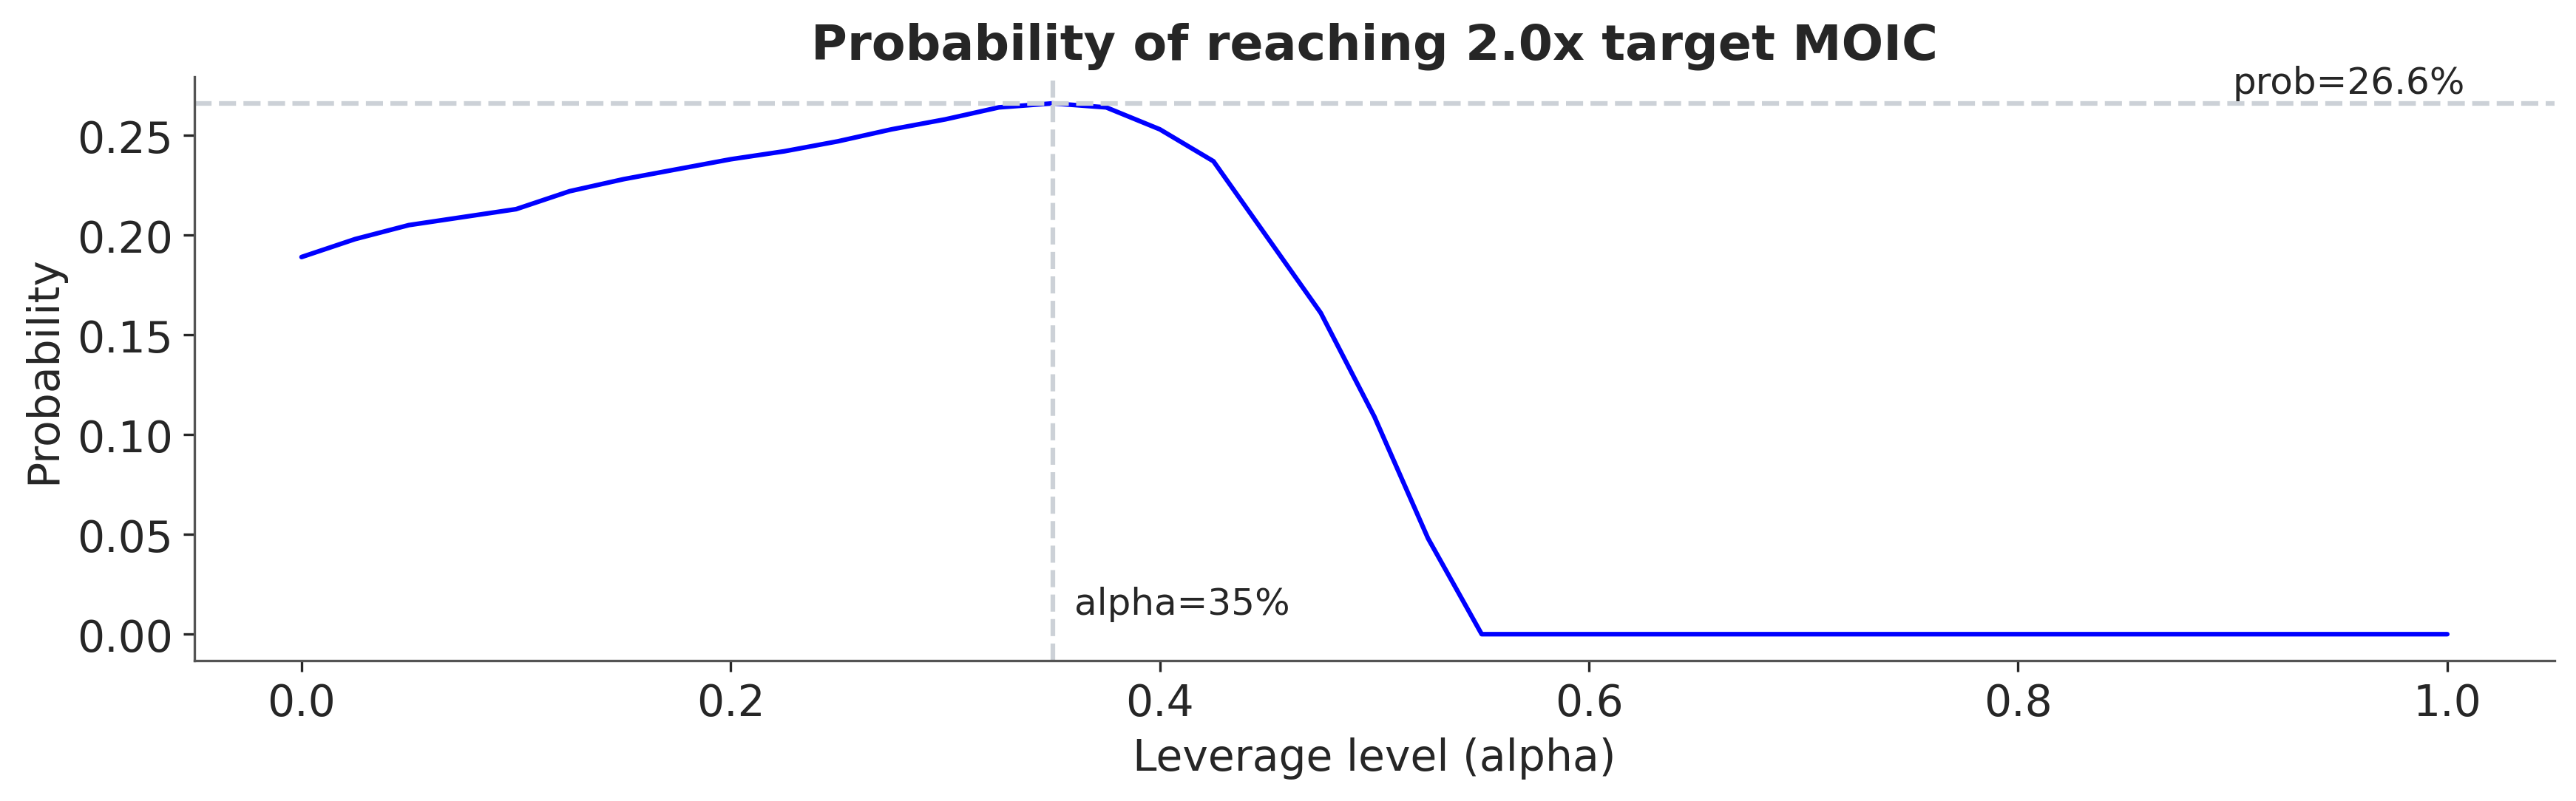

In [195]:

target_probs = []

spread = 0.05
params['r_bar'] = risk_free + spread

alpha_grid = np.linspace(0, 1, 41)

for alpha in alpha_grid:
    output = run_sim(
    params,
    n_steps=n_steps,
    n_paths=n_paths,
    T = T,
    t_exit=t_exit,
    alpha=alpha,
    seed=99,
    stochastic_ir = False,
    return_all = True
    )

    entry_equity = (output['V_entry'] - output['D'][:, 0].mean())

    interim_cf = output['CF'][:, :-1].sum(axis=1)
    final_cf = np.maximum(output['V_exit'] - output['D'][:, -1], 0)

    payoff = final_cf + interim_cf

    defaulted_mask = output['defaulted'][:, -1]
    payoff[defaulted_mask] = 0.0

    # MOIC
    moic = payoff / entry_equity

    target_prob = (moic > 2).sum() / len(moic)
    target_probs.append(target_prob)
    
fig, ax = plt.subplots(figsize=(11.5, 3.5))

ax.plot(alpha_grid, target_probs, color=cmap['blue'])
ax.axhline(max(target_probs), linestyle='--', color=cmap['grey'])
ax.axvline(alpha_grid[np.argmax(target_probs)], linestyle='--', color=cmap['grey'])

ax.set_xlabel('Leverage level (alpha)')
ax.set_ylabel('Probability')
ax.set_title('Probability of reaching 2.0x target MOIC')

ax.annotate(f'prob={max(target_probs):.1%}', (0.9, max(target_probs) + 0.005), fontsize=12)
ax.annotate(f'alpha={alpha_grid[np.argmax(target_probs)]:.0%}', (alpha_grid[np.argmax(target_probs)] + 0.01, 0.01), fontsize=12)


plt.savefig(f'images/{company}_moic_prob.png', dpi=200, bbox_inches='tight')